In [1]:
# DATA LOADING AND QUICK LOOK AT DATA STRUCTURE

import pandas as pd
import os

HOUSING_PATH = "datasets/housing"

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

# loading data
housing=load_housing_data()
# display data structure
housing.head()

# data is preprocessed, the median_income is tens of thousands of dollar (median_income[i] * 10000 = real_median_income)

# data information viewing
'''
housing.info()
housing["ocean_proximity"].value_counts()
housing.describe()
'''

'\nhousing.info()\nhousing["ocean_proximity"].value_counts()\nhousing.describe()\n'

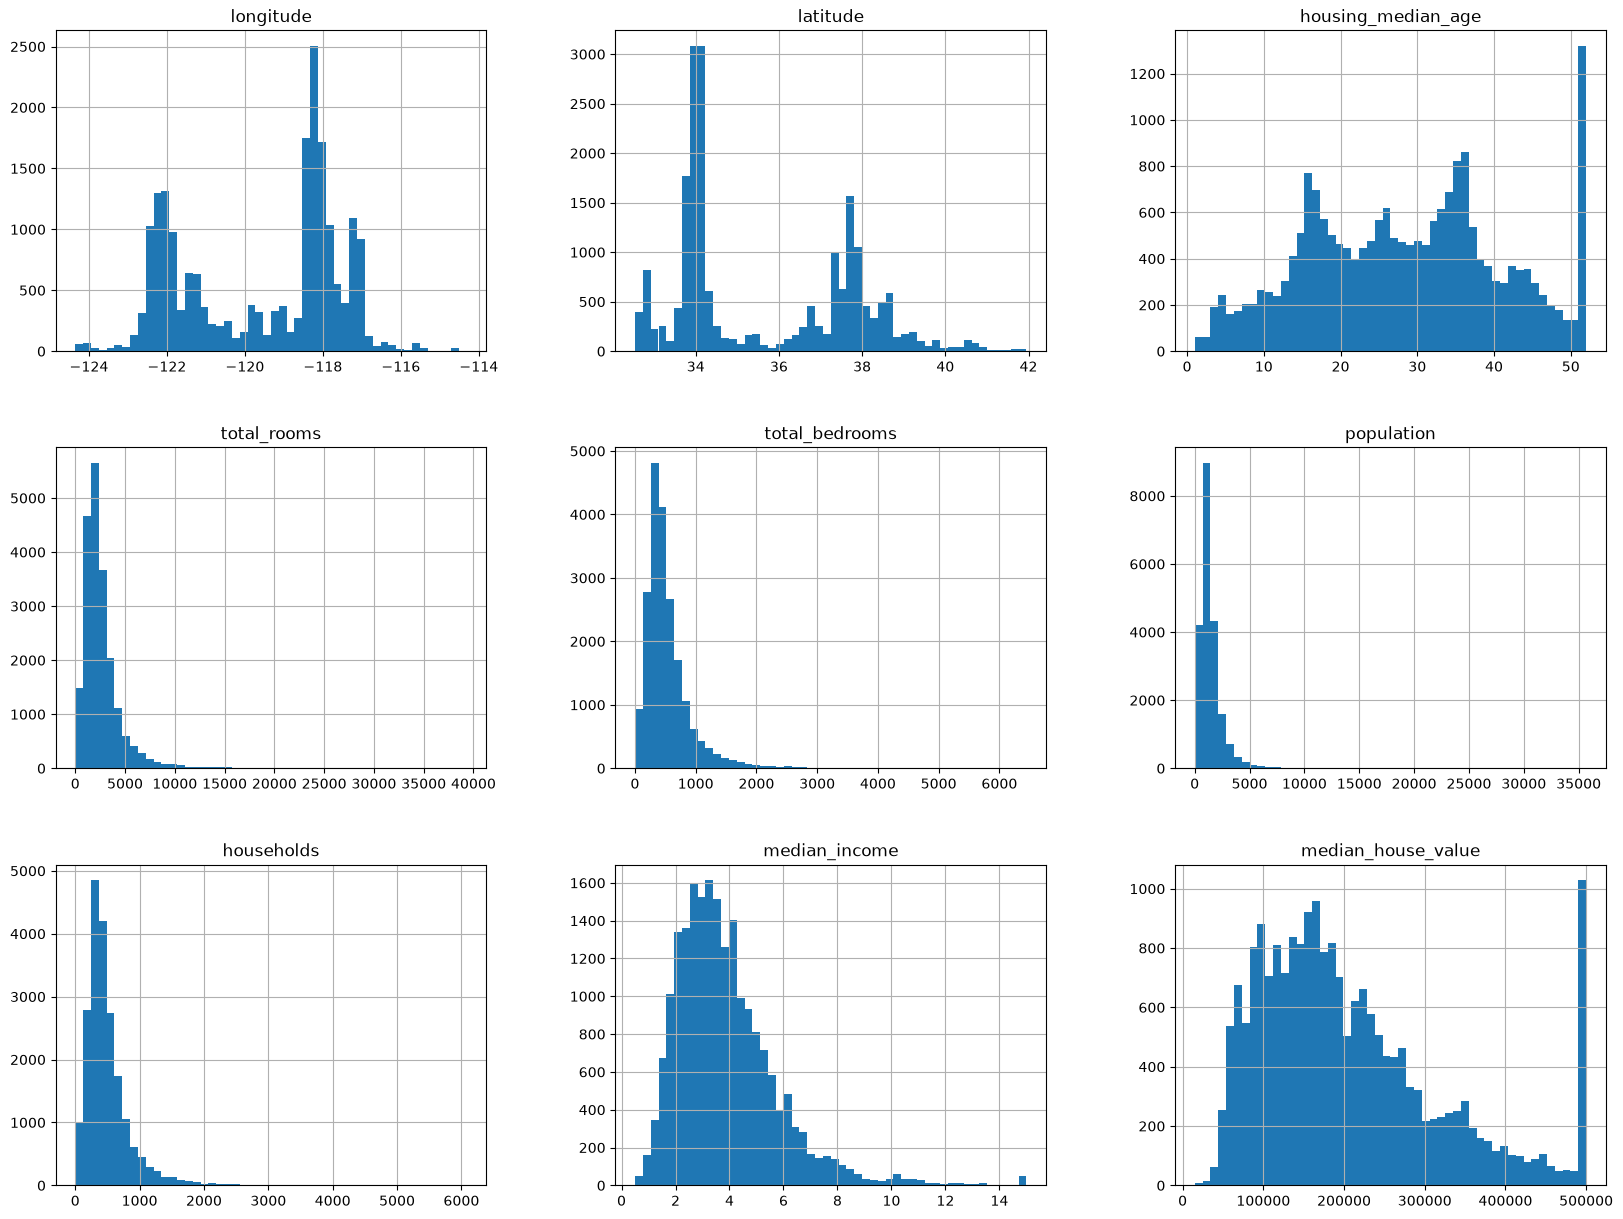

In [2]:
# DATA PLOT

%matplotlib inline

import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20,15))
plt.show()

# histogram representation of data features
# requires to be converted to bell shaped graph,(evenly distributed across mean) for better processing by model

In [3]:
# TRAINING AND TEST SET SPLITTING

import numpy as np

# this method creates test set by randomly choosing test_ratio % of instances from training set
# does not works as each time the test set will be random and even with seeding of random function, with new data the test set will change
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

'''
train_set, test_set = split_train_test(housing, 0.2)
print("Training set length : ", len(train_set))
print("Test set length : ", len(test_set))
'''

'\ntrain_set, test_set = split_train_test(housing, 0.2)\nprint("Training set length : ", len(train_set))\nprint("Test set length : ", len(test_set))\n'

In [4]:
# best way to get identical training set each time, even with updated data is by using each instance's identifier
# this data do not have identifiers for instances, but the row index can be used as ID
# the hash of ID can be computed and if the hash is lower than or equal to 20% of max hash value it can be included in training set

from zlib import crc32

def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

# split training set and test set using id
# adds index column to data 
'''
housing_with_id = housing.reset_index()
train_set_index, test_set_index = split_train_test_by_id(housing_with_id, 0.2, "index")
'''

# new data must be appended at last of each row and no row must be deleted.
# if not possible, then unique identifier must be created from the most stable features(longtitude and latitude in this case).
'''
housing_with_id = housing
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")
'''

# sklearn in build random train_test_split function
from sklearn.model_selection import train_test_split
'''
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
'''

In [5]:
# another way to create data sets is by choosing the test set, that is the representative of whole data
# in this case we choose median_income as an important features, and creates strata for median_income values,
# since most of the instances have median_income values between 0.5 to 6, we create 5 subgroups in this range,
# because it is important to have sufficient no of instances in each strata and not too many stratums

# this creates income category with 5 split/ranges
housing["income_cat"] = pd.cut(housing["median_income"],
                            bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                            labels=[1, 2, 3, 4, 5])
# displays the histogram for data ditruibution over median_income
'''
housing["income_cat"].hist()
'''

# this uses sklearn for stratified sampling of the above created feature
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# both the sets have same distribution for income_cat attribute
'''
print(strat_test_set["income_cat"].value_counts() / len(strat_test_set))
housing["income_cat"].value_counts() / len(housing)
'''

# removing income_cat attribute 
for set_ in (strat_test_set, strat_train_set):
    set_.drop("income_cat", axis=1, inplace=True)

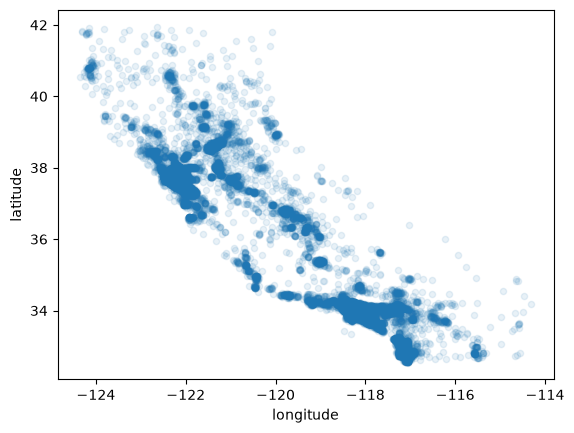

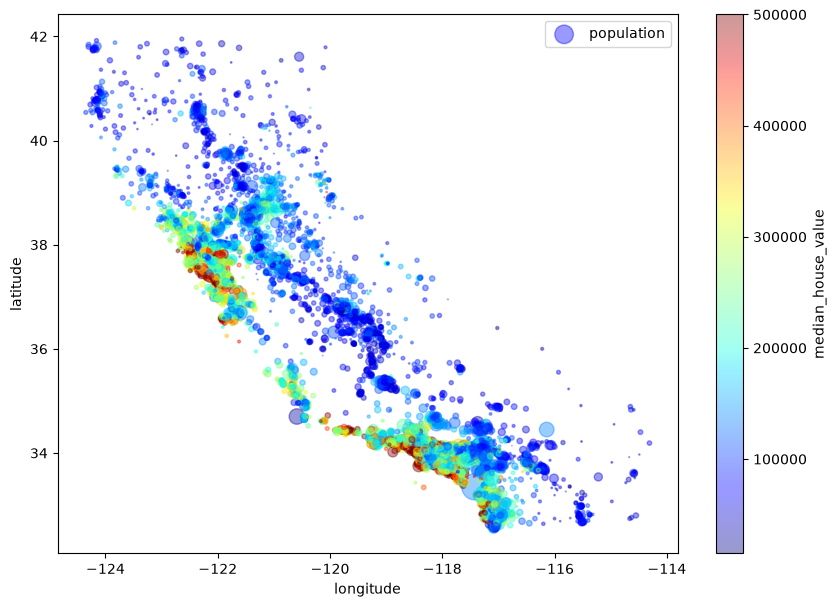

In [6]:
# VISUALISING DATA (TRAINING SET)

housing = strat_train_set.copy()

housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

# using plot for housing_prices, where radius of circle represent population and the color represents the price,
# using predefined color map jet (blue, low prices -> red, high prices)
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)
plt.legend()

In [7]:
# getting correlation between different attributes using standard coefficient correlation, it only measures linear correlation
# correlation values range from 1 to -1 where values close to 1 mean strong relation whereas close to -1 mean almost no relation
corr_matrix = housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

# another method is to use pandas scattering matrix plotting, which plots every numerical attributes against every other attribute
'''
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12,8))
'''

# median_house_income is the most promising attributes
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)
# this shows the strong correlation, upward trend (slope pattern) and not too dispersed points
# this also shows the housing_value cat at 500K and some straight line around 450K and 350K that needs to be removed to prevent algo's from learning these data quirks

ValueError: could not convert string to float: 'INLAND'

In [14]:
# CLEANING DATA

# assigning the missing values of total_bedrooms with median values from training set
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity", axis=1)
# imputer have the median values
imputer.fit(housing_num)

'''
print(imputer.statistics_)
print(housing_num.median().values)
'''

# array form of data with missing values replaced with median by transform() of imputer
X = imputer.transform(housing_num)
# create pandas DataFrame
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

# the text attributes i.e. ocean_proximity requires to be converted to numercial data
# can be converted as categorial attributes but this will relate closer attributes more but this can be wrong, for example
# 1-ocean 2-inland 3-near ocean, here 1 and 3 are more related than 1 and 2
# so using one-hot encoding instead
housing_cat = housing[["ocean_proximity"]]
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_onehot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_onehot.toarray())
print(cat_encoder.categories_)

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]